RAPPORT D'ANNOTATION et Audit du Dataset

In [154]:
import json
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# 1. CONFIGURATION

def charger_donnees(chemin_fichier):
    """Charge les données JSON avec gestion d'erreur."""
    try:
        with open(chemin_fichier, 'r', encoding='utf-8') as file:
            return json.load(file)
    except FileNotFoundError:
        print(f" ERREUR : Le fichier '{chemin_fichier}' est introuvable.")
        return None

#

In [155]:
def analyser_dataset(data, limite=100):
    """Effectue toute l'analyse logique du dataset."""
    stats = {
        "total_annotees": 0,
        "compteur_classes": Counter(),
        "pertinence_par_rang": {f"T{i}": {"total": 0, "pertinent": 0} for i in range(1, 7)},
        "erreurs_regle_seuil": [],
        "exemples_bruit": []
    }

    for ancre in data[:limite]:
        titre_ancre = ancre.get('news', 'Titre inconnu')
        
        if 'database' not in ancre:
            continue

        for index, cible in enumerate(ancre['database']):
            score = cible.get('similarity_annotation')
            relation = cible.get('related')
            
            if score is not None and relation is not None:
                stats["total_annotees"] += 1
                
                # Nettoyage et formatage
                score_float = float(score)
                relation_propre = str(relation).title().strip()
                nom_cible = f"T{index + 1}"
                
                # A. Comptage global
                stats["compteur_classes"][relation_propre] += 1
                
                # B. Pertinence par rang
                if nom_cible in stats["pertinence_par_rang"]:
                    stats["pertinence_par_rang"][nom_cible]["total"] += 1
                    if relation_propre in ["Supporting", "Opposing"]:
                        stats["pertinence_par_rang"][nom_cible]["pertinent"] += 1
                
                # C. Règle du Seuil
                if score_float <= 0.2 and relation_propre != "Not Related":
                    stats["erreurs_regle_seuil"].append({
                        "Position": nom_cible, "Score": score_float, "Relation": relation_propre
                    })
                
                # D. Faux Amis (Bruit T1/T2)
                if index < 2 and score_float > 0.5 and relation_propre in ["Not Related", "Undetermined"]:
                    stats["exemples_bruit"].append({
                        "Position": nom_cible, "Score": score_float, 
                        "Relation": relation_propre, "Ancre": titre_ancre, 
                        "Cible": cible.get('news', 'Titre inconnu')
                    })
    return stats

In [156]:
def afficher_rapport(stats):
    """Génère le rapport visuel dans la console avec alertes automatiques."""
    total = stats["total_annotees"]
    alertes = [] # Initialisation de la liste des alertes
   
    print(" AUDIT DE QUALITÉ DU DATASET (DATA ANALYST REPORT)")

    if total == 0:
        print(" Aucune donnée annotée trouvée.")
        return
    
    print(f"\n[1] ANALYSE DES CLASSES ({total} annotations)")
    
    # La boucle doit englober tout le calcul et le print
    for classe, count in stats["compteur_classes"].most_common():
        pourcentage = (count / total) * 100
        
        # Détermination du statut pour chaque classe
        status = ""
        if pourcentage < 5.0:
            status = "⚠️ [SOUS-REPRÉSENTÉE]"
            alertes.append(classe)
        
        # Affichage de la ligne pour CHAQUE classe
        print(f" - {classe:<15} : {count:3} ({pourcentage:5.1f}%) {status}")

    # Résumé des alertes après la boucle
    if alertes:
        print(f"\n ALERTE : Les classes suivantes sont critiques (< 5%) : {', '.join(alertes)}")
    else:
        print("\n Équilibre des classes : Aucune classe n'est en dessous de 5%.")

    # 2. Sanity Check
    print("\n[2] VÉRIFICATION DES RÈGLES (Seuil 0.2)")
    erreurs = stats["erreurs_regle_seuil"]
    if not erreurs:
        print(" 100% de conformité sur le seuil de score.")
    else:
        print(f" {len(erreurs)} erreur(s) détectée(s).")


In [157]:
def generer_rapport_diagnostic(chemin_csv):
    """Analyse le CSV pour générer les stats et lister les exceptions."""
    df = pd.read_csv(chemin_csv)
    
    # Statistiques de base
    total_cibles = len(df)
    nb_valides = df['relation'].notna().sum()
    nb_manquants = df['relation'].isna().sum()
    
    # Détection des exceptions (T3 à T6 avec Score > 0.2)
    bruit = df[~df['target_label'].isin(['T1', 'T2'])]
    exceptions = bruit[bruit['similarity_score'] > 0.2]

    print("RAPPORT DE DIAGNOSTIC")
    print(f"▶ Cibles vérifiées : {total_cibles}")
    print(f"▶ Annotations manquantes : {nb_manquants}")
    print(f"▶ Annotations valides : {nb_valides}")
    print(f"▶ Exceptions T3-T6 détectées : {len(exceptions)}")
    
    return exceptions

In [158]:

def generer_rapport(csv_path):
    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        print(f"Erreur : Le fichier {csv_path} est introuvable.")
        return

    # 2. Analyse de la Cohérence : Score moyen par Classe
    # Cela permet de vérifier si les 'Supporting' ont bien des scores plus hauts
    stats_classes = df.groupby('relation')['similarity_score'].agg(['mean', 'std', 'count']).reset_index()

    # 3. Analyse de la "Zone Grise" (Incertitude)
    # Les scores entre 0.4 et 0.6 sont souvent les plus difficiles pour l'IA
    zone_grise = df[(df['similarity_score'] >= 0.4) & (df['similarity_score'] <= 0.6)]
    repartition_grise = zone_grise['relation'].value_counts(normalize=True) * 100

    # 4. Détection des Anomalies Sémantiques (Bruit avec score élevé)
    # Par exemple, des 'Not Related' avec un score > 0.2 pourraient être des faux positifs
    anomalies = df[(df['relation'] == 'not_related') & (df['similarity_score'] > 0.2)]

    # --- VISUALISATION ---
    plt.figure(figsize=(12, 6))
    
    # Graphique : Boxplot de la distribution des scores
    sns.boxplot(x='relation', y='similarity_score', data=df, palette='Set2')
    plt.title('Fiabilité du Score de Similarité par Classe')
    plt.axhline(y=0.2, color='r', linestyle='--', label='Seuil de Bruit (0.2)')
    plt.legend()
    plt.savefig('analyse_distribution_scores.png')
    
    # --- AFFICHAGE DU RAPPORT ---
    print("RAPPORT D'AUDIT DE DONNÉES - DATA ANALYST")
  

    print(f"\n[1] VALIDATION STATISTIQUE DES CLASSES :")
    print(stats_classes.to_string(index=False))
    
    print(f"\n[3] DIAGNOSTIC DES FAUX POSITIFS :")
    print(f" - Nombre d'alertes (Not Related > 0.2) : {len(anomalies)}")
    if len(anomalies) > 0:
        print(" - Top 3 des cibles à haut risque (Faux Positifs) :")
        print(anomalies[['target_label', 'similarity_score', 'target_title']].head(3).to_string(index=False))

    print("\n" + "="*50)
    print("Graphique sauvegardé : analyse_distribution_scores.png")
    return anomalies


Fichier extractions_report.csv enregistré avec succès.
 AUDIT DE QUALITÉ DU DATASET (DATA ANALYST REPORT)

[1] ANALYSE DES CLASSES (600 annotations)
 - Not_Related     : 409 ( 68.2%) 
 - Supporting      :  95 ( 15.8%) 
 - Undetermined    :  88 ( 14.7%) 
 - Against         :   8 (  1.3%) ⚠️ [SOUS-REPRÉSENTÉE]

 ALERTE : Les classes suivantes sont critiques (< 5%) : Against

[2] VÉRIFICATION DES RÈGLES (Seuil 0.2)
 417 erreur(s) détectée(s).

RAPPORT DE DIAGNOSTIC
▶ Cibles vérifiées : 12000
▶ Annotations manquantes : 11214
▶ Annotations valides : 786
▶ Exceptions T3-T6 détectées : 5


C:\Users\user\AppData\Local\Temp\ipykernel_13876\612617258.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='relation', y='similarity_score', data=df, palette='Set2')


RAPPORT D'AUDIT DE DONNÉES - DATA ANALYST

[1] VALIDATION STATISTIQUE DES CLASSES :
    relation     mean      std  count
     against 0.681818 0.125045     11
 not_related 0.013594 0.073692    537
  supporting 0.693600 0.147421    125
undetermined 0.518584 0.218987    113

[3] DIAGNOSTIC DES FAUX POSITIFS :
 - Nombre d'alertes (Not Related > 0.2) : 10
 - Top 3 des cibles à haut risque (Faux Positifs) :
target_label  similarity_score                                                                                     target_title
          T4               0.5 Harvey Weinstein raped additional women, prosecutor says, but yet to file new charges - ABC News
          T1               0.7             Lauren Boebert Rages Against Plan That Could Keep Republicans Off Ballots - Newsweek
          T5               0.5                                Mom of 4 says ‘everyone's helping their kids too much’ - ABC News

Graphique sauvegardé : analyse_distribution_scores.png


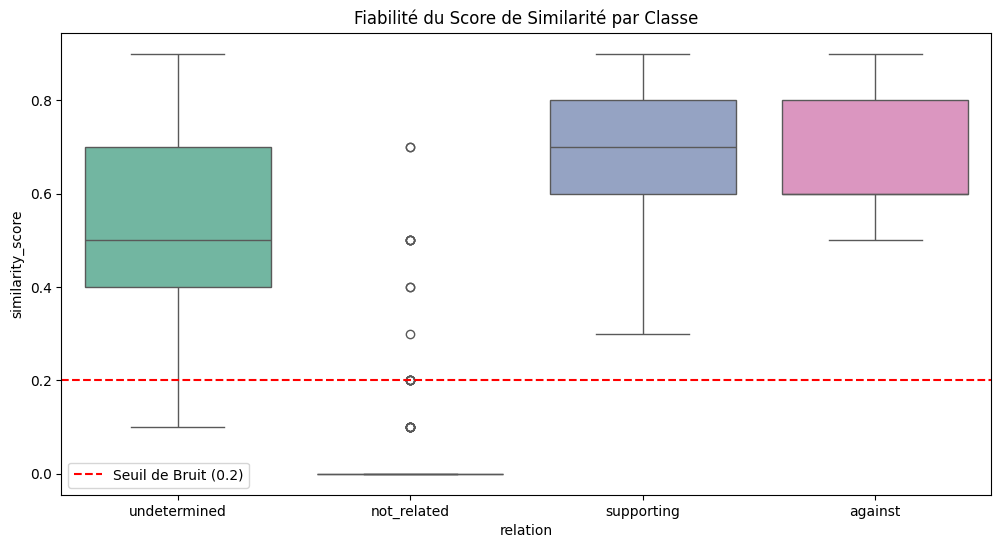

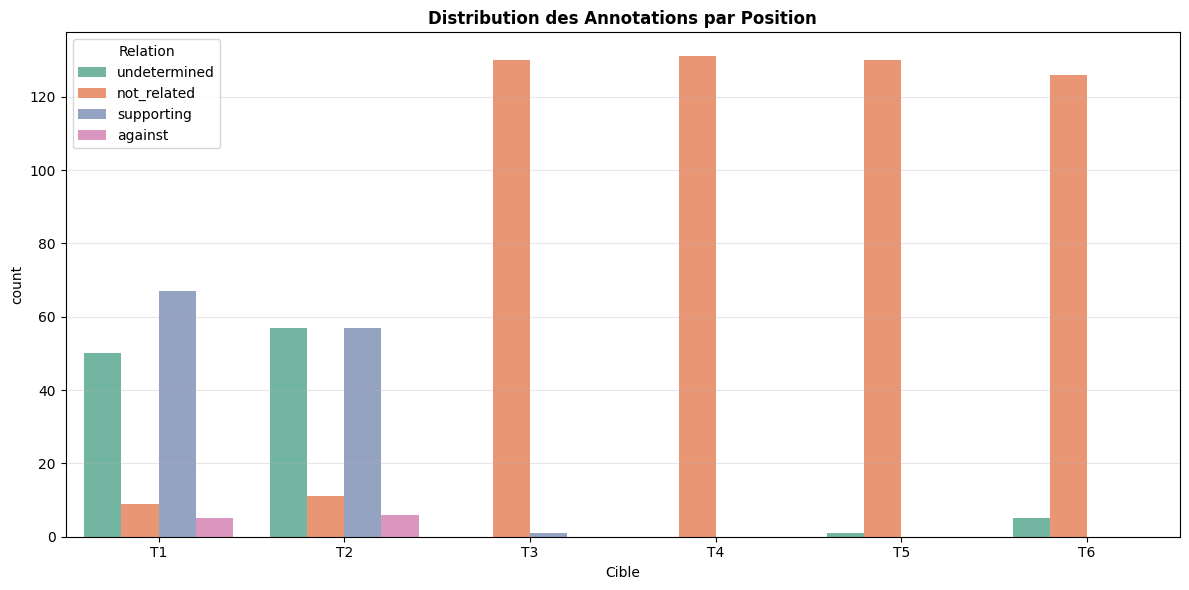

 Matrice sauvegardée sous : rapport_visuel.png


Relation,against,not_related,supporting,undetermined
Tranche_Score,,,,
0.0-0.2,0,527,0,17
0.2-0.4,0,3,4,18
0.4-0.6,6,5,46,47
0.6-0.8,4,2,60,26
0.8-1.0,1,0,15,5


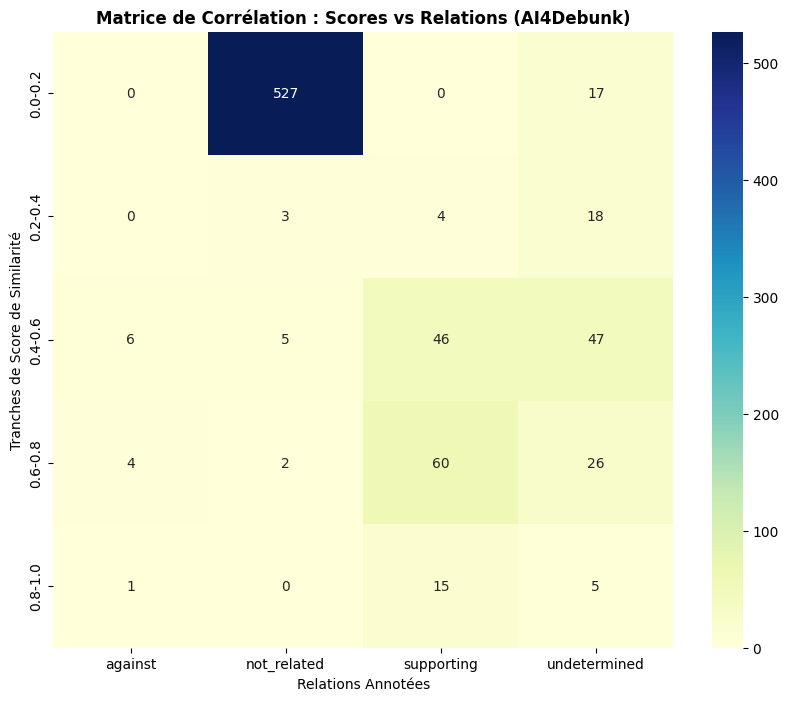

In [159]:
import importlib
import extraction 
import visualisation 

# On force la mise à jour si tu as modifié les fichiers .py
importlib.reload(extraction)
importlib.reload(visualisation)

from extraction import *
from visualisation import *

FICHIER = 'vldbench_batch_01.json'
CSV_EXTRAIT = 'extractions_report.csv'

# --- ÉTAPE 1 : EXTRACTION (Indispensable en premier) ---
extract_to_csv(FICHIER, output_filename=CSV_EXTRAIT)

# --- ÉTAPE 2 : CHARGEMENT & ANALYSE DU JSON (Optionnel) ---
mes_donnees = charger_donnees(FICHIER)
if mes_donnees:
    resultats = analyser_dataset(mes_donnees)
    afficher_rapport(resultats)
    

# --- ÉTAPE 3 : RAPPORTS ET GRAPHIQUES (Basés sur le CSV) ---
# On utilise maintenant le fichier CSV généré à l'étape 1
generer_rapport_diagnostic(CSV_EXTRAIT)
generer_rapport(CSV_EXTRAIT)
generer_graphique_relations(CSV_EXTRAIT)
generer_rapport_visuel(CSV_EXTRAIT, output_image="rapport_visuel.png")

# interpretation
le dataset est fortement déséquilibré, avec une surreprésentation de la classe Not_Related (68.2%) et une sous-représentation critique de Against (1.3%).
Cela peut entraîner un biais du modèle vers la classe majoritaire.
Pour améliorer :

Appliquer un rééquilibrage des classes (SMOTE / undersampling)
Vérifier les règles de seuil (0.2 peut être trop bas)
Corriger ou supprimer les faux positifs
# Conclusion
Le dataset présente des problèmes majeurs de qualité, notamment un grand nombre d’annotations manquantes (93%) et un déséquilibre de classes important.
Sans correction, ces problèmes peuvent fortement dégrader la performance des modèles de machine learning.


